<a href="https://colab.research.google.com/github/RidhoAnfaal/PCVK_Ganjil_2025/blob/main/Week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
import google.colab.drive
google.colab.drive.mount('/content/drive')

Mounted at /content/drive


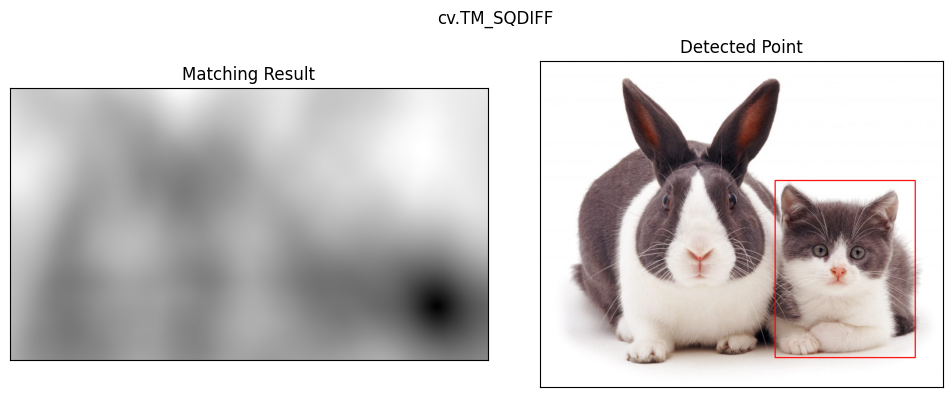

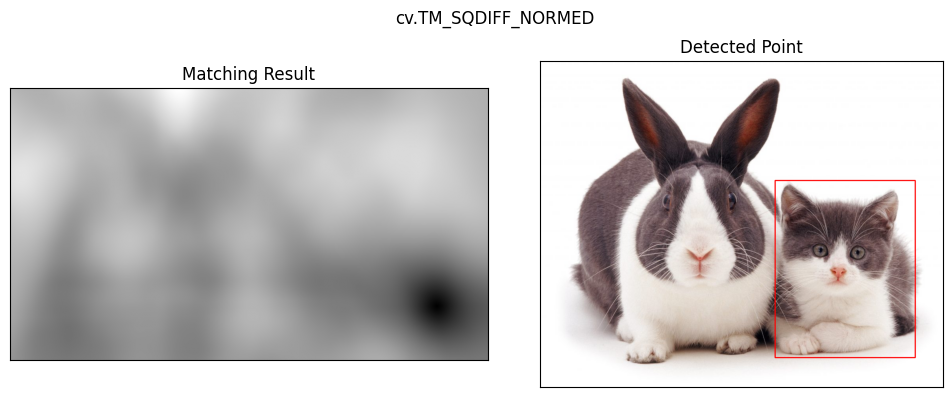

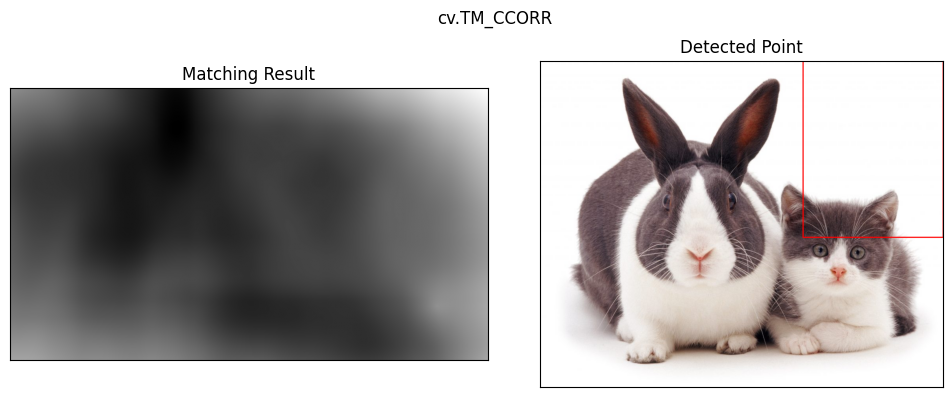

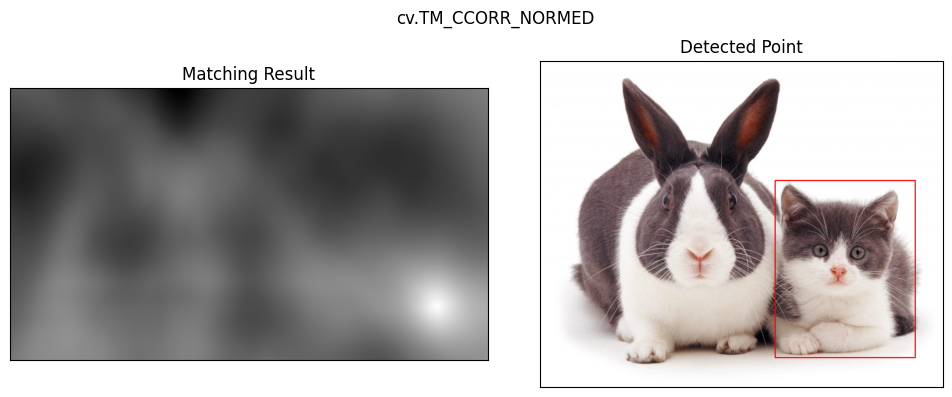

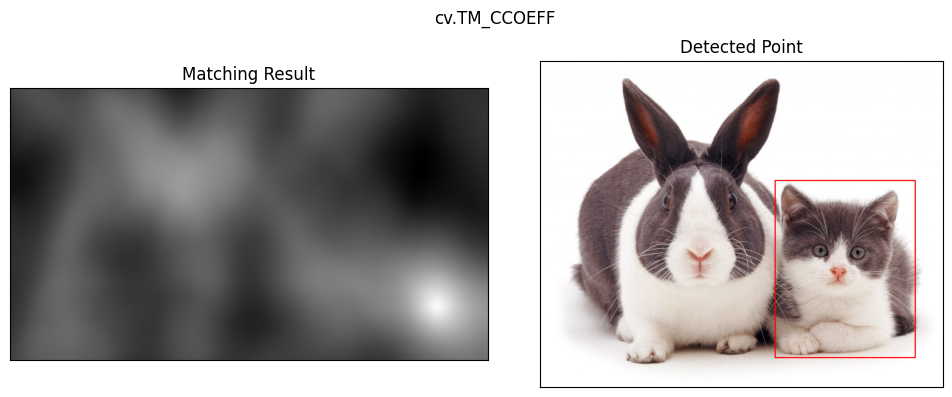

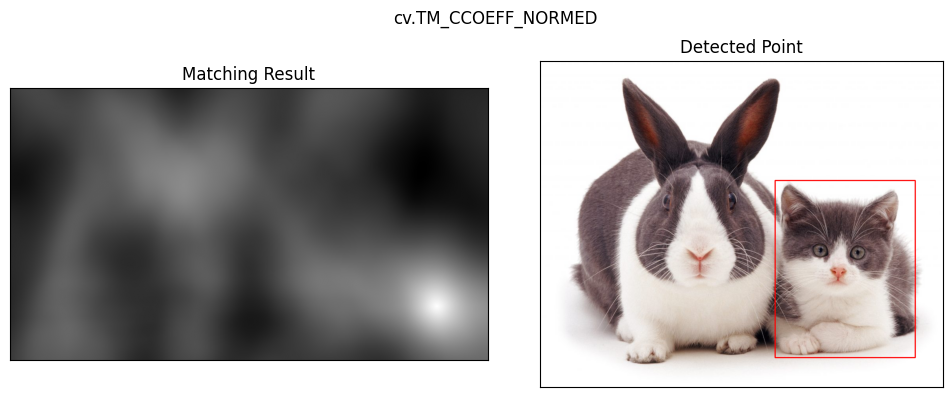

In [7]:
img_rgb = cv.imread('/content/drive/MyDrive/PCVK/cats_and_bunnies.jpg')
template = cv.imread('/content/drive/MyDrive/PCVK/cat2_templatejpg.jpg')

img_gray = cv.cvtColor(img_rgb, cv.COLOR_BGR2GRAY)
template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)

w, h = template_gray.shape[::-1]

methods = [
    'cv.TM_SQDIFF',
    'cv.TM_SQDIFF_NORMED',
    'cv.TM_CCORR',
    'cv.TM_CCORR_NORMED',
    'cv.TM_CCOEFF',
    'cv.TM_CCOEFF_NORMED'
]

for meth in methods:
    img_copy = img_rgb.copy()
    method = eval(meth)

    res = cv.matchTemplate(img_gray, template_gray, method)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    bottom_right = (top_left[0] + w, top_left[1] + h)

    cv.rectangle(img_copy, top_left, bottom_right, (0, 0, 255), 2)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(res, cmap='gray')
    plt.title('Matching Result')
    plt.xticks([]), plt.yticks([])

    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(img_copy, cv.COLOR_BGR2RGB))
    plt.title('Detected Point')
    plt.xticks([]), plt.yticks([])

    plt.suptitle(meth)
    plt.tight_layout()
    plt.show()

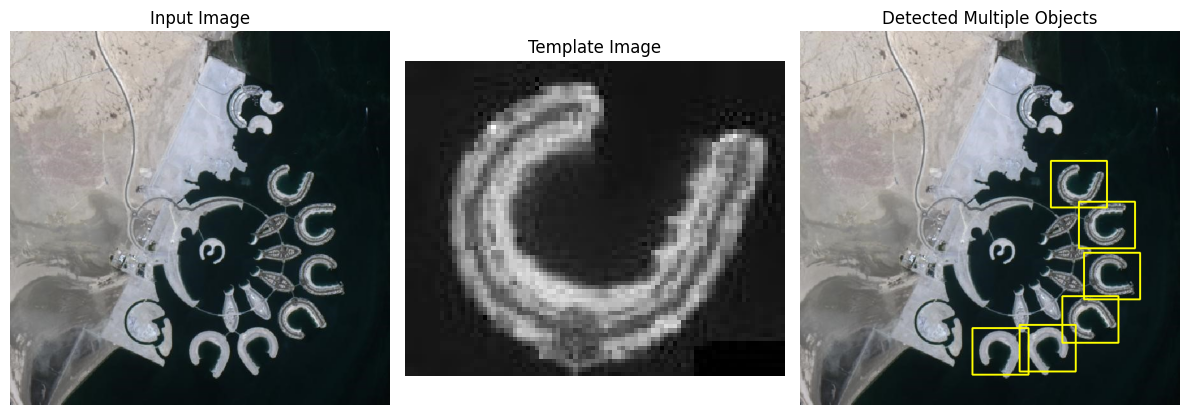

In [16]:
img_rgb = cv.imread('/content/drive/MyDrive/PCVK/bahrain.jpg')
template = cv.imread('/content/drive/MyDrive/PCVK/bahrain-template.jpg', 0)
img_gray = cv.cvtColor(img_rgb, cv.COLOR_BGR2GRAY)

w, h = template.shape[::-1]

result = cv.matchTemplate(img_gray, template, cv.TM_CCOEFF_NORMED)

threshold = 0.45
locations = np.where(result >= threshold)

rectangles = [
    [int(x), int(y), int(w), int(h)]
    for (x, y) in zip(*locations[::-1])
]

boxes, _ = cv.groupRectangles(rectangles, groupThreshold=1, eps=0.2)

detected_img = img_rgb.copy()
for (x, y, w, h) in boxes:
    cv.rectangle(detected_img, (x, y), (x + w, y + h), (0, 255, 255), 2)

img_rgb = cv.cvtColor(img_rgb, cv.COLOR_BGR2RGB)
detected_rgb = cv.cvtColor(detected_img, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(template, cmap='gray')
plt.title('Template Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(detected_rgb)
plt.title('Detected Multiple Objects')
plt.axis('off')

plt.tight_layout()
plt.show()

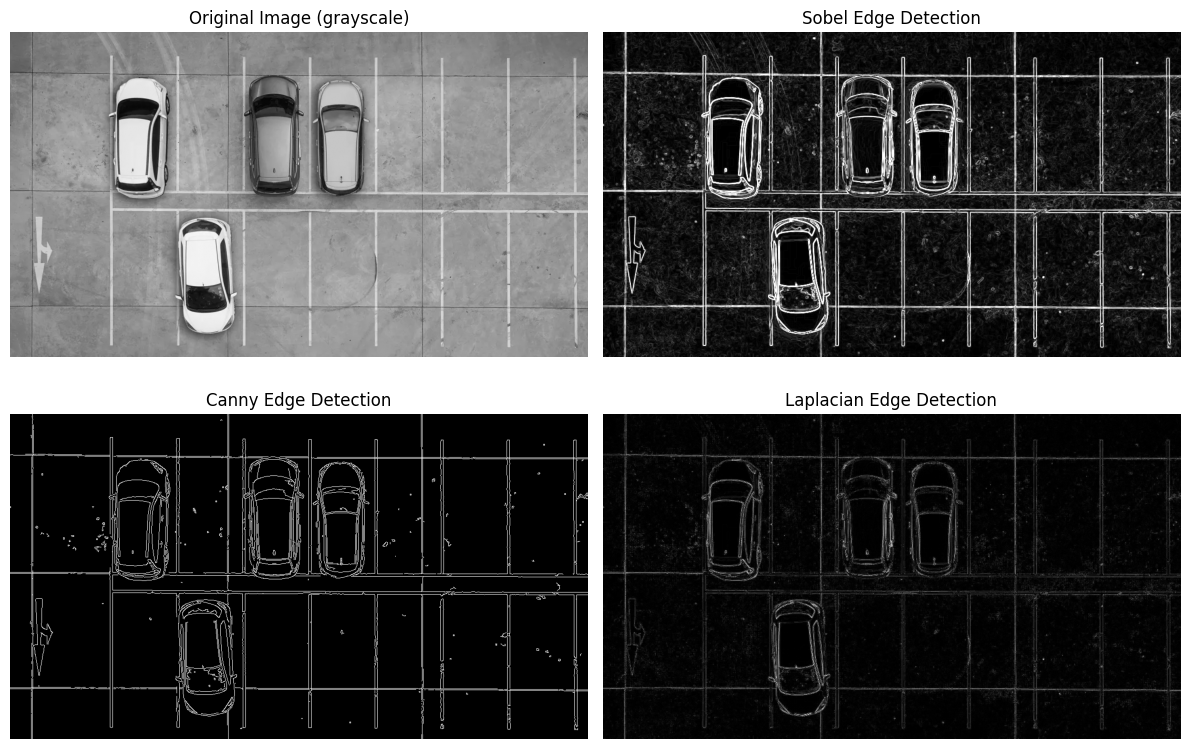

In [18]:
img = cv.imread('/content/drive/MyDrive/PCVK/car-park.jpg', cv.IMREAD_GRAYSCALE)

sobel_x = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=3)
sobel_y = cv.Sobel(img, cv.CV_64F, 0, 1, ksize=3)
sobel_combined = cv.magnitude(sobel_x, sobel_y)
sobel_combined = cv.convertScaleAbs(sobel_combined)

canny_edges = cv.Canny(img, 100, 200)

laplacian = cv.Laplacian(img, cv.CV_64F)
laplacian = cv.convertScaleAbs(laplacian)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image (grayscale)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(canny_edges, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian Edge Detection')
plt.axis('off')

plt.tight_layout()
plt.show()

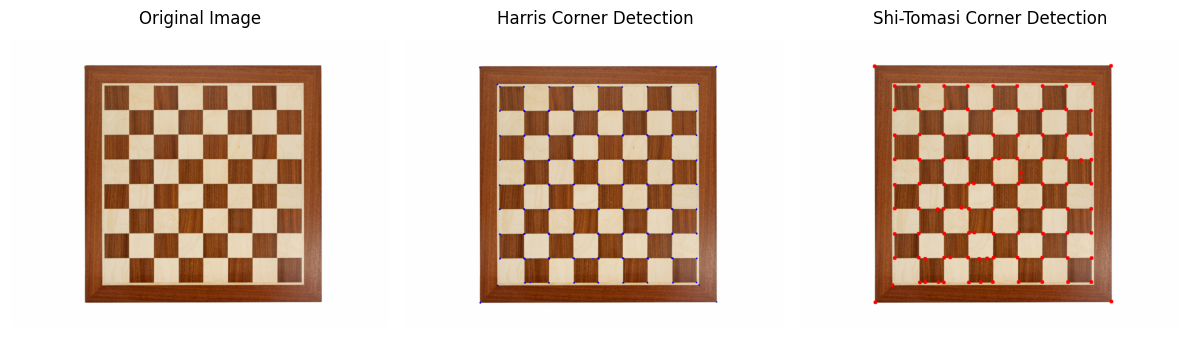

In [22]:
img = cv.imread('/content/drive/MyDrive/PCVK/chess-board.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

gray_float = np.float32(gray)
harris_corners = cv.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)

harris_corners = cv.dilate(harris_corners, None)

img_harris = img.copy()
img_harris[harris_corners > 0.01 * harris_corners.max()] = [255, 0, 0]

shi_tomasi_corners = cv.goodFeaturesToTrack(gray, maxCorners=100, qualityLevel=0.01, minDistance=10)
shi_tomasi_corners = shi_tomasi_corners.astype(int)

img_shi = img.copy()
for c in shi_tomasi_corners:
    x, y = c.ravel()
    cv.circle(img_shi, (x, y), 5, (0, 0, 255), -1)

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(img_harris, cv.COLOR_BGR2RGB))
plt.title('Harris Corner Detection')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(img_shi, cv.COLOR_BGR2RGB))
plt.title('Shi-Tomasi Corner Detection')
plt.axis('off')

plt.tight_layout()
plt.show()

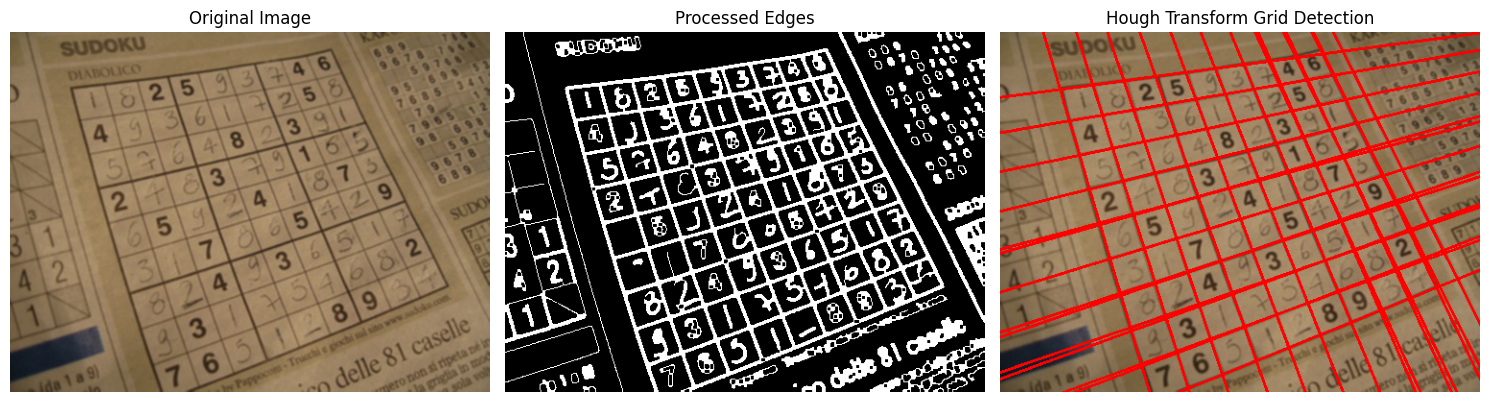

In [26]:
img = cv.imread('/content/drive/MyDrive/PCVK/sudoku.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

edges = cv.Canny(gray, 50, 150, apertureSize=3)

kernel = np.ones((3, 3), np.uint8)
processed = cv.morphologyEx(edges, cv.MORPH_CLOSE, kernel, iterations=1)

lines = cv.HoughLines(processed, 1, np.pi / 175, 290)

img_hough = img.copy()
if lines is not None:
    for rho, theta in lines[:, 0]:
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a * rho, b * rho
        x1, y1 = int(x0 + 1000 * (-b)), int(y0 + 1000 * (a))
        x2, y2 = int(x0 - 1000 * (-b)), int(y0 - 1000 * (a))
        cv.line(img_hough, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(processed, cmap='gray')
plt.title('Processed Edges')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(img_hough, cv.COLOR_BGR2RGB))
plt.title('Hough Transform Grid Detection')
plt.axis('off')

plt.tight_layout()
plt.show()

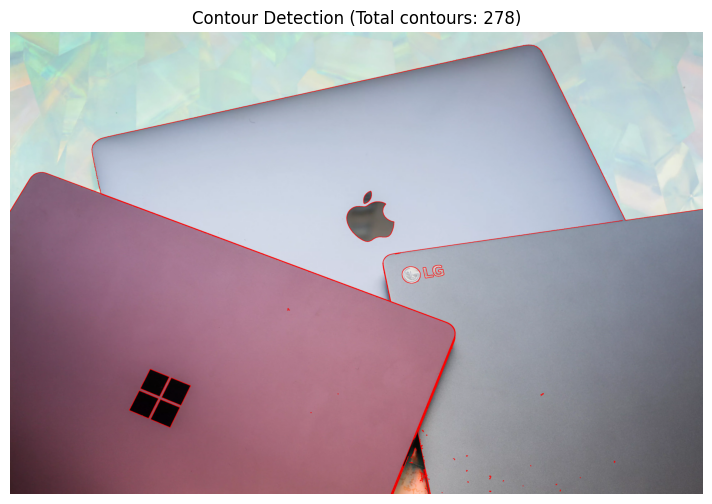

In [28]:
img = cv.imread('/content/drive/MyDrive/PCVK/laptop.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

edges = cv.Canny(gray, 50, 150)

contours, _ = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

img_contour = img.copy()
cv.drawContours(img_contour, contours, -1, (0, 0, 255), 2)

img_rgb = cv.cvtColor(img_contour, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title(f'Contour Detection (Total contours: {len(contours)})')
plt.axis('off')
plt.show()

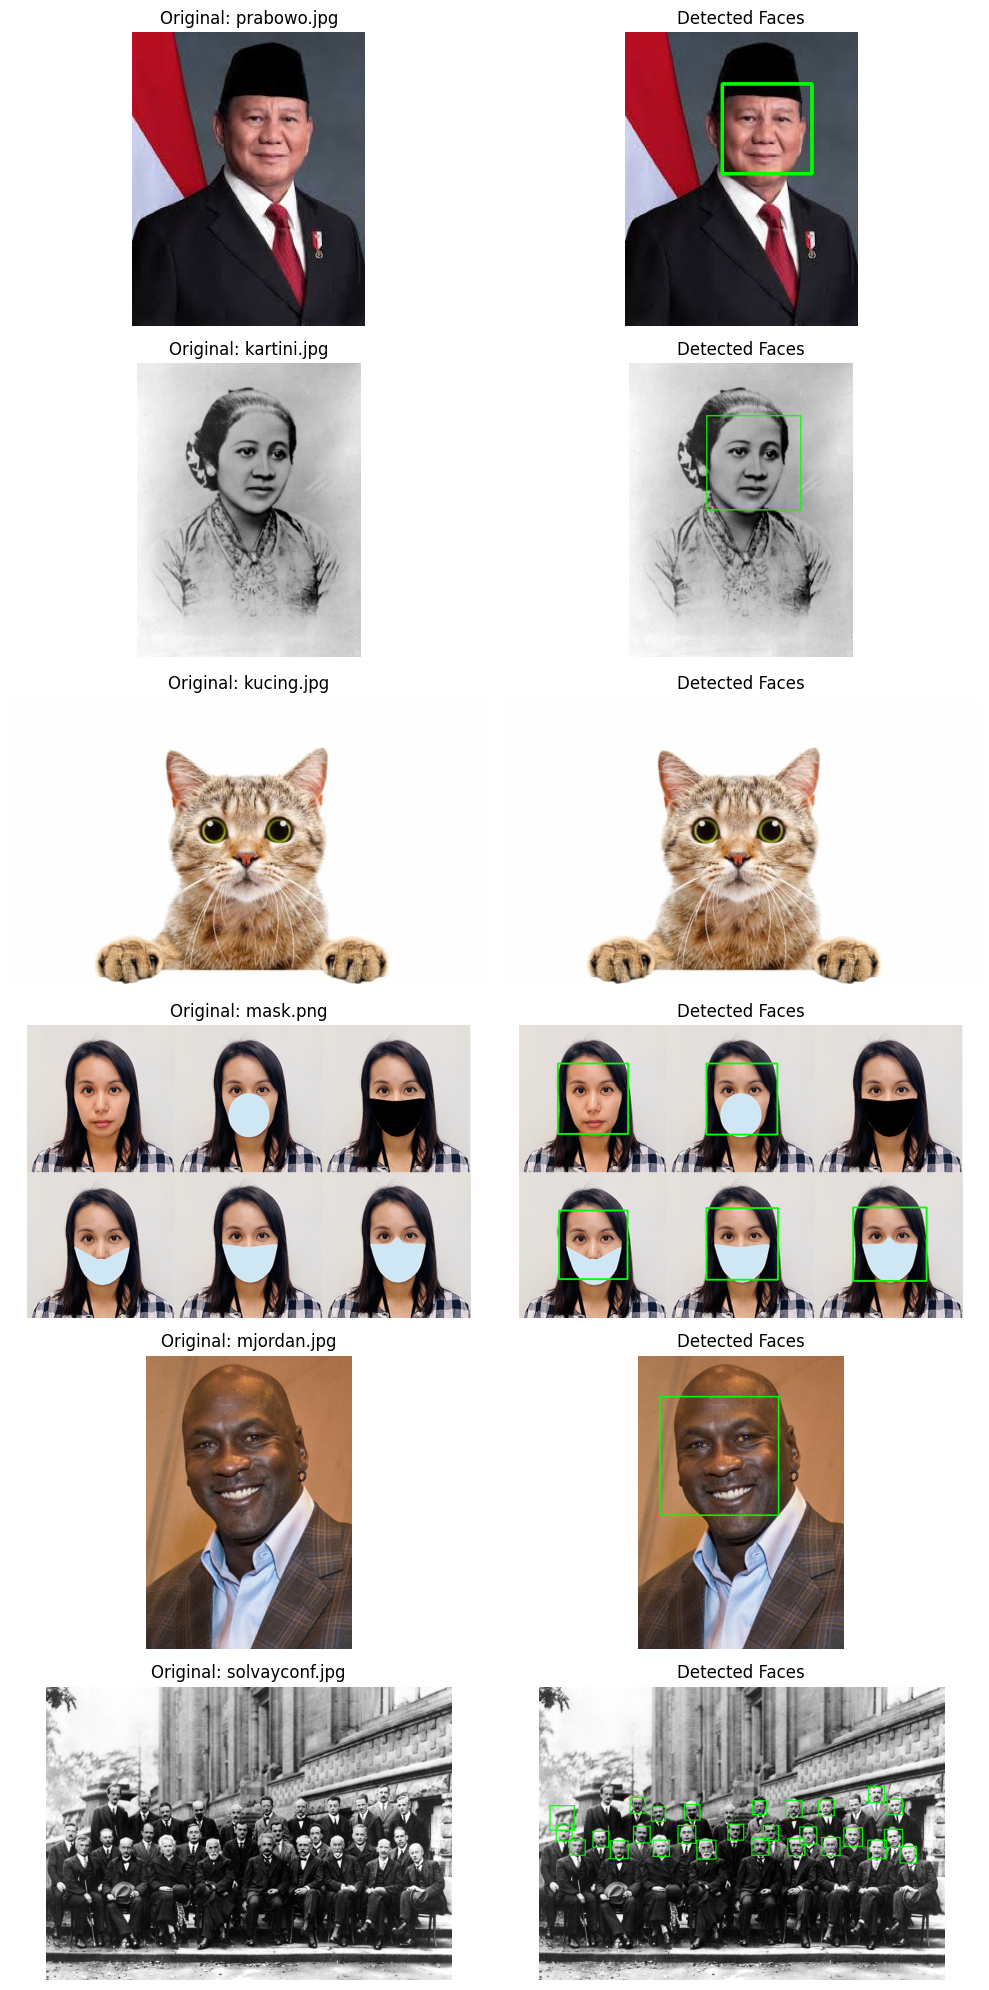

In [36]:
cascade_path = '/content/drive/MyDrive/PCVK/haarcascades/haarcascade_frontalface_alt.xml'

face_cascade = cv.CascadeClassifier(cascade_path)

image_filenames = [
    'prabowo.jpg',
    'kartini.jpg',
    'kucing.jpg',
    'mask.png',
    'mjordan.jpg',
    'solvayconf.jpg'
]

base_path = '/content/drive/MyDrive/PCVK/'

fig, axs = plt.subplots(len(image_filenames), 2, figsize=(10, 20))

for i, filename in enumerate(image_filenames):
    img_path = base_path + filename

    img_color = cv.imread(img_path)
    if img_color is None:
        print(f"[Warning] Gagal membaca file: {img_path}")
        continue

    img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        img_gray,
        scaleFactor=1.1,
        minNeighbors=4,
        minSize=(30, 30)
    )

    img_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)
    img_detected = img_rgb.copy()

    for (x, y, w, h) in faces:
        cv.rectangle(img_detected, (x, y), (x + w, y + h), (0, 255, 0), 2)

    axs[i, 0].imshow(img_rgb)
    axs[i, 0].set_title(f'Original: {filename}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(img_detected)
    axs[i, 1].set_title('Detected Faces')
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()

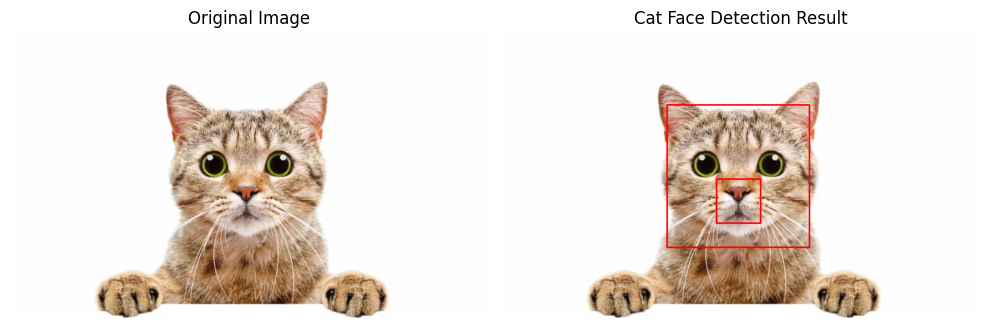

In [39]:
cat_cascade_path = '/content/drive/MyDrive/PCVK/haarcascades/haarcascade_frontalcatface.xml'

cat_cascade = cv.CascadeClassifier(cat_cascade_path)

if cat_cascade.empty():
    print(f"[Error] Tidak dapat memuat file cascade: {cat_cascade_path}")
else:
    img_path = '/content/drive/MyDrive/PCVK/kucing.jpg'

    img_color = cv.imread(img_path)
    if img_color is None:
        print(f"[Error] Gagal membaca gambar: {img_path}")
    else:
        img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

        cat_faces = cat_cascade.detectMultiScale(
            img_gray,
            scaleFactor=1.03,
            minNeighbors=3,
            minSize=(50, 50)
        )

        img_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)

        img_detected = img_rgb.copy()

        for (x, y, w, h) in cat_faces:
            cv.rectangle(img_detected, (x, y), (x + w, y + h), (255, 0, 0), 2)

        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(img_rgb)
        plt.title('Original Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(img_detected)
        plt.title('Cat Face Detection Result')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

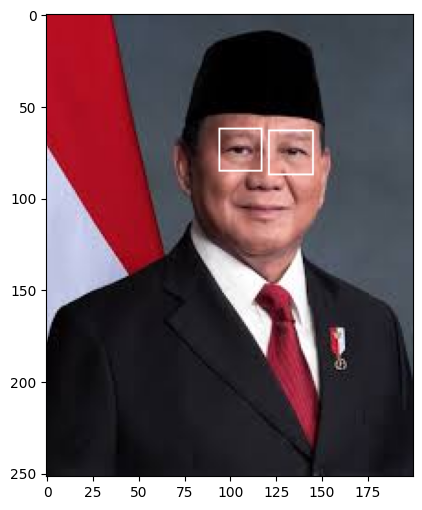

In [51]:
face_cascade = cv.CascadeClassifier('/content/drive/MyDrive/PCVK/haarcascades/haarcascade_frontalface_alt.xml')
eye_cascade = cv.CascadeClassifier('/content/drive/MyDrive/PCVK/haarcascades/haarcascade_eye.xml')

img_path = '/content/drive/MyDrive/PCVK/prabowo.jpg'
img_color = cv.imread(img_path)
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=5)

img_detected = img_color.copy()

eyes_detected = []

if len(faces) > 0:
    for (x, y, w, h) in faces:
        roi_gray = img_gray[y:y+h, x:x+w]
        roi_color = img_detected[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.05, minNeighbors=3)
        for (ex, ey, ew, eh) in eyes:
            eyes_detected.append((x+ex, y+ey, ew, eh))
else:
    eyes = eye_cascade.detectMultiScale(img_gray, scaleFactor=1.05, minNeighbors=3)
    for (ex, ey, ew, eh) in eyes:
        eyes_detected.append((ex, ey, ew, eh))

for (ex, ey, ew, eh) in eyes_detected:
    cv.rectangle(img_detected, (ex, ey), (ex+ew, ey+eh), (255, 255, 255), 1)

img_rgb = cv.cvtColor(img_detected, cv.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.show()

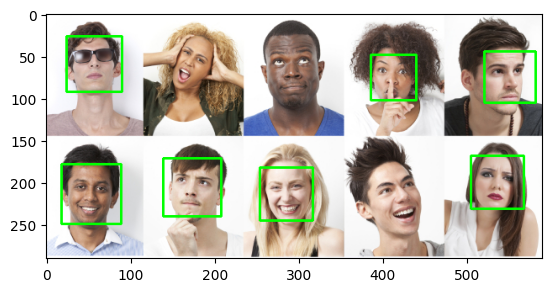

In [67]:
face_cascade = cv.CascadeClassifier('/content/drive/MyDrive/PCVK/haarcascades/haarcascade_frontalface_alt.xml')
smile_cascade = cv.CascadeClassifier('/content/drive/MyDrive/PCVK/haarcascades/haarcascade_smile.xml')

img_path = '/content/drive/MyDrive/PCVK/people.jpg'
img_color = cv.imread(img_path)
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.3, minNeighbors=5)
img_copy = img_color.copy()

for (x, y, w, h) in faces:
    roi_gray = img_gray[y:y+h, x:x+w]
    roi_color = img_copy[y:y+h, x:x+w]

    smiles = smile_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.3,
        minNeighbors=15,
        minSize=(30, 30)
    )

    cv.rectangle(img_copy, (x, y), (x+w, y+h), (0, 255, 0), 2)

    for (sx, sy, sw, sh) in smiles:
        cv.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)

img_rgb = cv.cvtColor(img_copy, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.show()


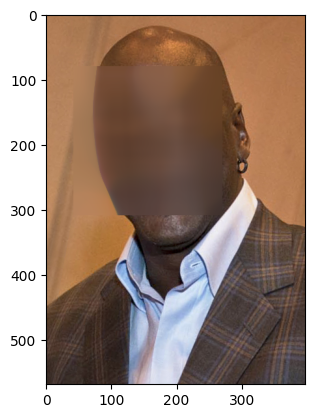

In [65]:
face_cascade_path = '/content/drive/MyDrive/PCVK/haarcascades/haarcascade_frontalface_alt.xml'
face_cascade = cv.CascadeClassifier(face_cascade_path)

img_path = '/content/drive/MyDrive/PCVK/mjordan.jpg'
img_color = cv.imread(img_path)
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(img_gray, 1.1, 4)

img_color_copy = img_color.copy()

for (x, y, w, h) in faces:
    face_roi = img_color_copy[y:y+h, x:x+w]

    blurred_face = cv.medianBlur(face_roi, 99)

    img_color_copy[y:y+h, x:x+w] = blurred_face

img_rgb = cv.cvtColor(img_color_copy, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.show()

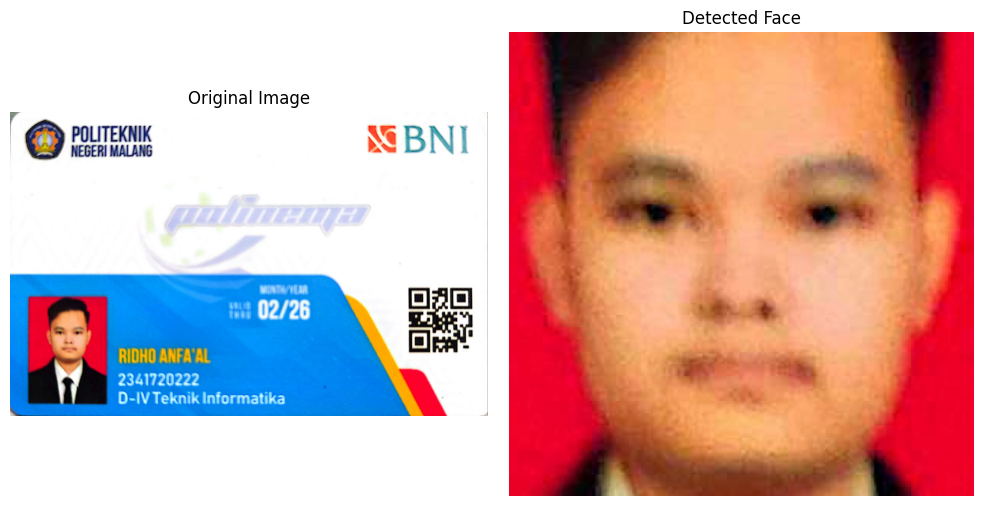

In [77]:
face_cascade_path = '/content/drive/MyDrive/PCVK/haarcascades/haarcascade_frontalface_alt.xml'
face_cascade = cv.CascadeClassifier(face_cascade_path)

img_path = '/content/drive/MyDrive/PCVK/ktmRidho_1.jpg'
img_color = cv.imread(img_path)
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(img_gray, 1.1, 4)

if len(faces) > 0:
    (x, y, w, h) = faces[0]
    photo_roi = img_color[y:y+h, x:x+w]

    photo_rgb = cv.cvtColor(photo_roi, cv.COLOR_BGR2RGB)
    img_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(photo_rgb)
    plt.title('Detected Face')
    plt.axis('off')

    plt.tight_layout()
    plt.show()